# F1 Lap-Level Data â€” Exploratory Data Analysis

Exploring lap-by-lap timing, tire degradation, pit strategy, and position changes across 2018â€“2025 seasons.
Data collected via FastF1 (2018â€“2024) and Jolpica API (2025).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)

LAPS_DIR = Path("..") / "data" / "raw" / "laps"

# Load lap data
combined_path = LAPS_DIR / "all_laps.parquet"
if combined_path.exists():
    laps = pd.read_parquet(combined_path)
    print("Loaded combined lap data")
else:
    season_files = sorted(LAPS_DIR.glob("laps_*.parquet"))
    laps = pd.concat([pd.read_parquet(f) for f in season_files], ignore_index=True)
    print(f"Loaded {len(season_files)} season files")

print(f"Shape: {laps.shape}")
print(f"Seasons: {sorted(laps['season'].unique())}")
print(f"Races per season: {laps.groupby('season')['round'].nunique().to_dict()}")
laps.head()

Loaded combined lap data
Shape: (165128, 19)
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Races per season: {2018: 21, 2019: 21, 2020: 17, 2021: 22, 2022: 22, 2023: 22, 2024: 24, 2025: 24}


,season,round,event_name,driver_abbrev,team,lap_number,lap_time_sec,sector_1_sec,sector_2_sec,sector_3_sec,position,tire_compound,tire_life,stint,is_pit_in_lap,is_pit_out_lap,track_status,is_personal_best,pit_duration_sec
0,2018,1,Australian Grand Prix,GAS,Toro Rosso,1,105.060,NaN,25.495,37.955,17.0,None,NaN,NaN,False,False,,False,NaN
1,2018,1,Australian Grand Prix,GAS,Toro Rosso,2,93.372,31.357,24.825,37.190,17.0,None,1.0,1.0,False,False,,True,NaN
2,2018,1,Australian Grand Prix,GAS,Toro Rosso,3,92.861,31.160,24.725,36.976,17.0,None,2.0,1.0,False,False,,True,NaN
3,2018,1,Australian Grand Prix,GAS,Toro Rosso,4,92.184,30.835,24.730,36.619,17.0,None,3.0,1.0,False,False,,True,NaN
4,2018,1,Australian Grand Prix,GAS,Toro Rosso,5,92.332,30.716,24.821,36.795,17.0,None,4.0,1.0,False,False,21,False,NaN


## 1. Dataset Overview

In [2]:
print("Column types:")
print(laps.dtypes.to_string())
print(f"\nTotal laps: {len(laps):,}")
print(f"Unique drivers: {laps['driver_abbrev'].nunique()}")
print(f"Unique races: {laps.groupby(['season', 'round']).ngroups}")
print(f"\nNull counts:")
nulls = laps.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False).to_string())

# Null breakdown by season (FastF1 vs Jolpica)
print("\n--- Null % by season (key columns) ---")
key_cols = ["lap_time_sec", "sector_1_sec", "tire_compound", "track_status", "position"]
existing_cols = [c for c in key_cols if c in laps.columns]
null_pct = laps.groupby("season")[existing_cols].apply(lambda g: g.isnull().mean() * 100).round(1)
print(null_pct.to_string())

Column types:
season                int64
round                 int64
event_name           object
driver_abbrev        object
team                 object
lap_number            int64
lap_time_sec        float64
sector_1_sec        float64
sector_2_sec        float64
sector_3_sec        float64
position            float64
tire_compound        object
tire_life           float64
stint               float64
is_pit_in_lap          bool
is_pit_out_lap         bool
track_status         object
is_personal_best       bool
pit_duration_sec    float64

Total laps: 165,128
Unique drivers: 43
Unique races: 173

Null counts:
pit_duration_sec    165052
tire_compound        14445
sector_1_sec          5911
sector_3_sec          2892
lap_time_sec          2814
sector_2_sec          2736
track_status          2400
tire_life              978
stint                  343
position               261

--- Null % by season (key columns) ---
        lap_time_sec  sector_1_sec  tire_compound  track_status  positio

## 2. Lap Time Distribution

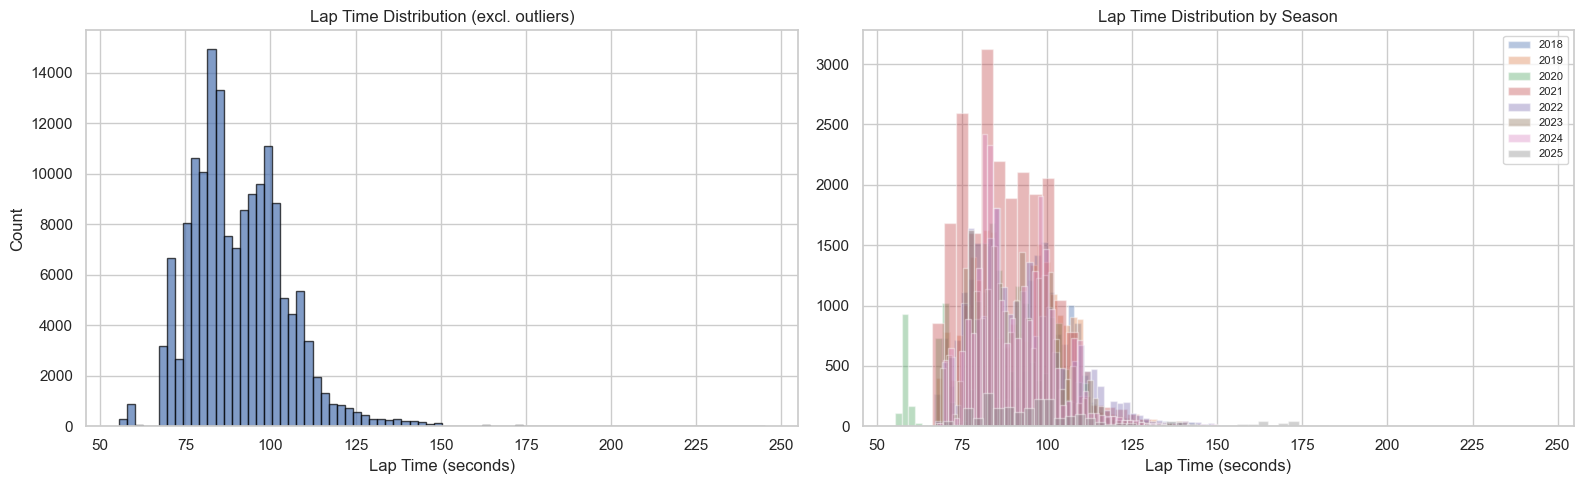


Median lap time by season:
season
2018    90.744
2019    91.625
2020    85.978
2021    86.748
2022    90.177
2023    89.646
2024    88.610
2025    97.689


In [3]:
valid_laps = laps.dropna(subset=["lap_time_sec"]).copy()
# Filter out outliers (pit laps, SC laps) â€” keep laps within 1.5x median
median_time = valid_laps.groupby(["season", "round"])["lap_time_sec"].transform("median")
clean_laps = valid_laps[valid_laps["lap_time_sec"] < median_time * 1.5].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall lap time distribution
clean_laps["lap_time_sec"].hist(bins=80, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("Lap Time Distribution (excl. outliers)")
axes[0].set_xlabel("Lap Time (seconds)")
axes[0].set_ylabel("Count")

# Lap time distribution by season
seasons_to_plot = sorted(clean_laps["season"].unique())
for season in seasons_to_plot:
    s_data = clean_laps[clean_laps["season"] == season]["lap_time_sec"]
    axes[1].hist(s_data, bins=50, alpha=0.4, label=str(season))
axes[1].set_title("Lap Time Distribution by Season")
axes[1].set_xlabel("Lap Time (seconds)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nMedian lap time by season:")
print(clean_laps.groupby("season")["lap_time_sec"].median().round(3).to_string())

## 3. Tire Compound Analysis

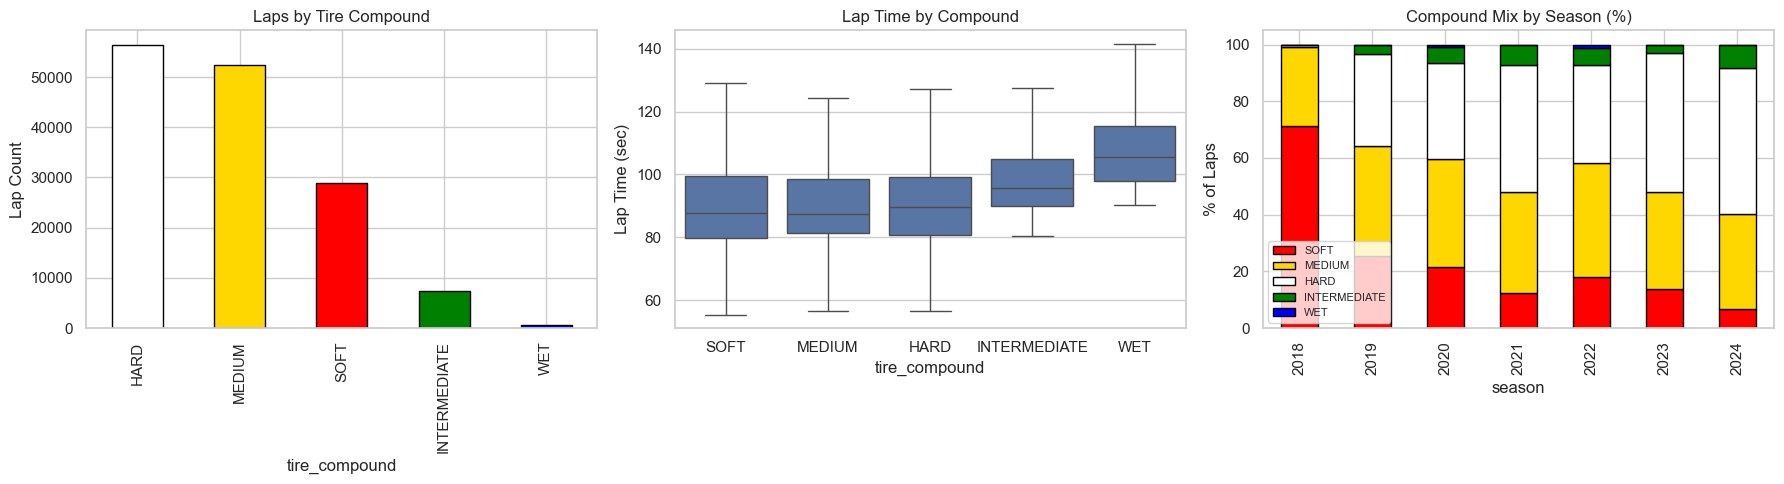

In [4]:
tire_laps = clean_laps.dropna(subset=["tire_compound"]).copy()

if len(tire_laps) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Compound usage
    compound_counts = tire_laps["tire_compound"].value_counts()
    colors = {"SOFT": "red", "MEDIUM": "gold", "HARD": "white", "INTERMEDIATE": "green", "WET": "blue"}
    bar_colors = [colors.get(c, "gray") for c in compound_counts.index]
    compound_counts.plot(kind="bar", ax=axes[0], color=bar_colors, edgecolor="black")
    axes[0].set_title("Laps by Tire Compound")
    axes[0].set_ylabel("Lap Count")

    # Lap time by compound
    compound_order = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
    existing = [c for c in compound_order if c in tire_laps["tire_compound"].values]
    sns.boxplot(data=tire_laps[tire_laps["tire_compound"].isin(existing)],
                x="tire_compound", y="lap_time_sec", order=existing, ax=axes[1],
                showfliers=False)
    axes[1].set_title("Lap Time by Compound")
    axes[1].set_ylabel("Lap Time (sec)")

    # Compound usage by season
    compound_season = tire_laps.groupby(["season", "tire_compound"]).size().unstack(fill_value=0)
    compound_season_pct = compound_season.div(compound_season.sum(axis=1), axis=0) * 100
    plot_cols = [c for c in compound_order if c in compound_season_pct.columns]
    compound_season_pct[plot_cols].plot(kind="bar", stacked=True, ax=axes[2],
                                        color=[colors.get(c, "gray") for c in plot_cols],
                                        edgecolor="black")
    axes[2].set_title("Compound Mix by Season (%)")
    axes[2].set_ylabel("% of Laps")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No tire compound data available (Jolpica-only dataset).")

## 4. Tire Degradation Curves

Lap time vs tire life by compound â€” the core signal for the time-series model.

C:\Users\jchiriyankandath\AppData\Local\Temp\ipykernel_52924\741649946.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stint_dry, x="compound", y="stint_length", order=dry_compounds, ax=axes[1],


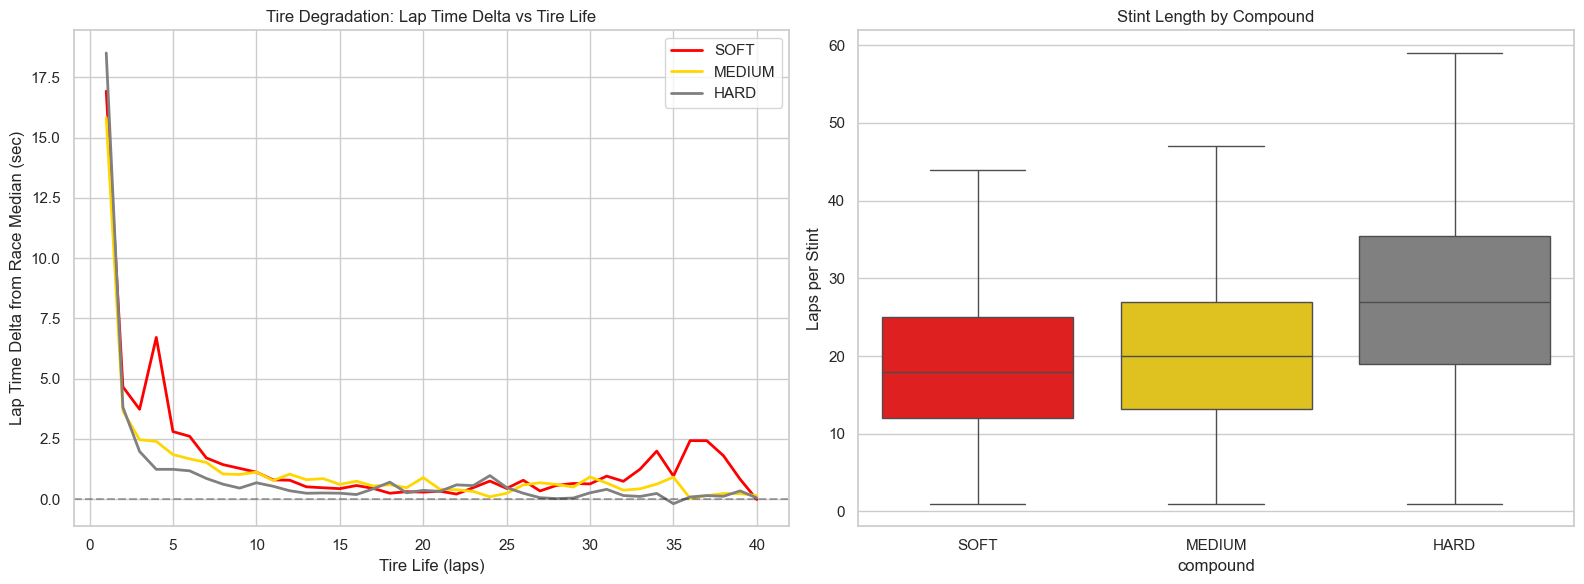

In [5]:
tire_deg = clean_laps.dropna(subset=["tire_compound", "tire_life"]).copy()

if len(tire_deg) > 0:
    # Normalize lap times per race to make degradation comparable
    race_median = tire_deg.groupby(["season", "round"])["lap_time_sec"].transform("median")
    tire_deg["lap_time_delta"] = tire_deg["lap_time_sec"] - race_median

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Degradation curve by compound (mean delta vs tire life)
    for compound in ["SOFT", "MEDIUM", "HARD"]:
        c_data = tire_deg[(tire_deg["tire_compound"] == compound) & (tire_deg["tire_life"] <= 40)]
        if len(c_data) > 0:
            deg_curve = c_data.groupby("tire_life")["lap_time_delta"].mean()
            color = {"SOFT": "red", "MEDIUM": "gold", "HARD": "gray"}[compound]
            axes[0].plot(deg_curve.index, deg_curve.values, label=compound, color=color, linewidth=2)

    axes[0].set_title("Tire Degradation: Lap Time Delta vs Tire Life")
    axes[0].set_xlabel("Tire Life (laps)")
    axes[0].set_ylabel("Lap Time Delta from Race Median (sec)")
    axes[0].legend()
    axes[0].axhline(y=0, color="black", linestyle="--", alpha=0.3)

    # Average tire life per stint by compound
    stint_length = tire_deg.groupby(["season", "round", "driver_abbrev", "stint"])["tire_life"].max()
    stint_compound = tire_deg.groupby(["season", "round", "driver_abbrev", "stint"])["tire_compound"].first()
    stint_df = pd.DataFrame({"stint_length": stint_length, "compound": stint_compound}).reset_index()
    dry_compounds = ["SOFT", "MEDIUM", "HARD"]
    stint_dry = stint_df[stint_df["compound"].isin(dry_compounds)]
    sns.boxplot(data=stint_dry, x="compound", y="stint_length", order=dry_compounds, ax=axes[1],
                showfliers=False, palette={"SOFT": "red", "MEDIUM": "gold", "HARD": "gray"})
    axes[1].set_title("Stint Length by Compound")
    axes[1].set_ylabel("Laps per Stint")

    plt.tight_layout()
    plt.show()
else:
    print("No tire degradation data available.")

## 5. Pit Stop Analysis

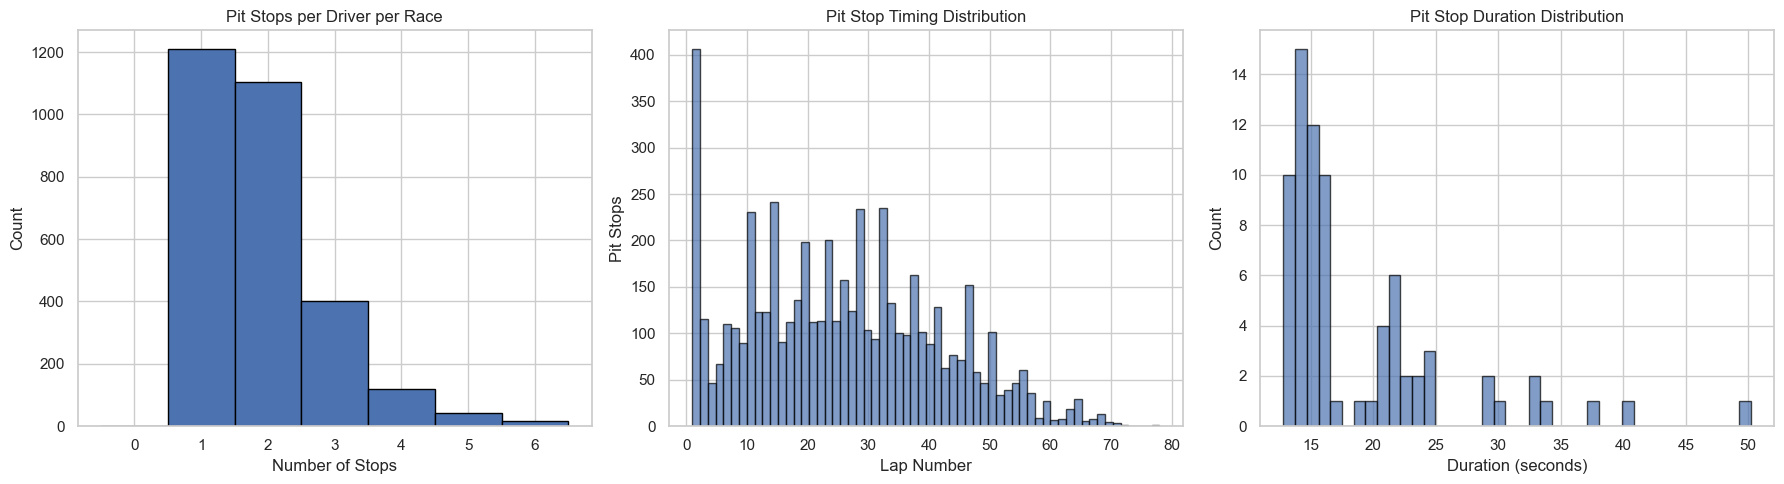


Pit stops per race (avg): 1.87
Most common stop count: 1

Total pit laps: 5,412


In [6]:
pit_laps = laps[laps["is_pit_in_lap"] == True].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pit stops per race per driver
stops_per_driver = pit_laps.groupby(["season", "round", "driver_abbrev"]).size()
stops_per_driver.hist(bins=range(0, 8), ax=axes[0], edgecolor="black", align="left")
axes[0].set_title("Pit Stops per Driver per Race")
axes[0].set_xlabel("Number of Stops")
axes[0].set_ylabel("Count")

# Pit stop lap distribution (when do people pit?)
pit_laps["lap_number"].hist(bins=60, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("Pit Stop Timing Distribution")
axes[1].set_xlabel("Lap Number")
axes[1].set_ylabel("Pit Stops")

# Pit duration distribution (if available)
if "pit_duration_sec" in pit_laps.columns:
    pit_durations = pit_laps["pit_duration_sec"].dropna()
    if len(pit_durations) > 0:
        pit_durations[pit_durations < 60].hist(bins=40, ax=axes[2], edgecolor="black", alpha=0.7)
        axes[2].set_title("Pit Stop Duration Distribution")
        axes[2].set_xlabel("Duration (seconds)")
        axes[2].set_ylabel("Count")
    else:
        axes[2].text(0.5, 0.5, "No pit duration data", ha="center", va="center",
                     transform=axes[2].transAxes)
else:
    axes[2].text(0.5, 0.5, "No pit duration column", ha="center", va="center",
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

print(f"\nPit stops per race (avg): {stops_per_driver.mean():.2f}")
print(f"Most common stop count: {stops_per_driver.mode().iloc[0]}")
print(f"\nTotal pit laps: {len(pit_laps):,}")

## 6. Position Changes & Overtaking

C:\Users\jchiriyankandath\AppData\Local\Temp\ipykernel_52924\1871079709.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_count = pos_laps.groupby("season").apply(lambda g: g.groupby("round").ngroups)


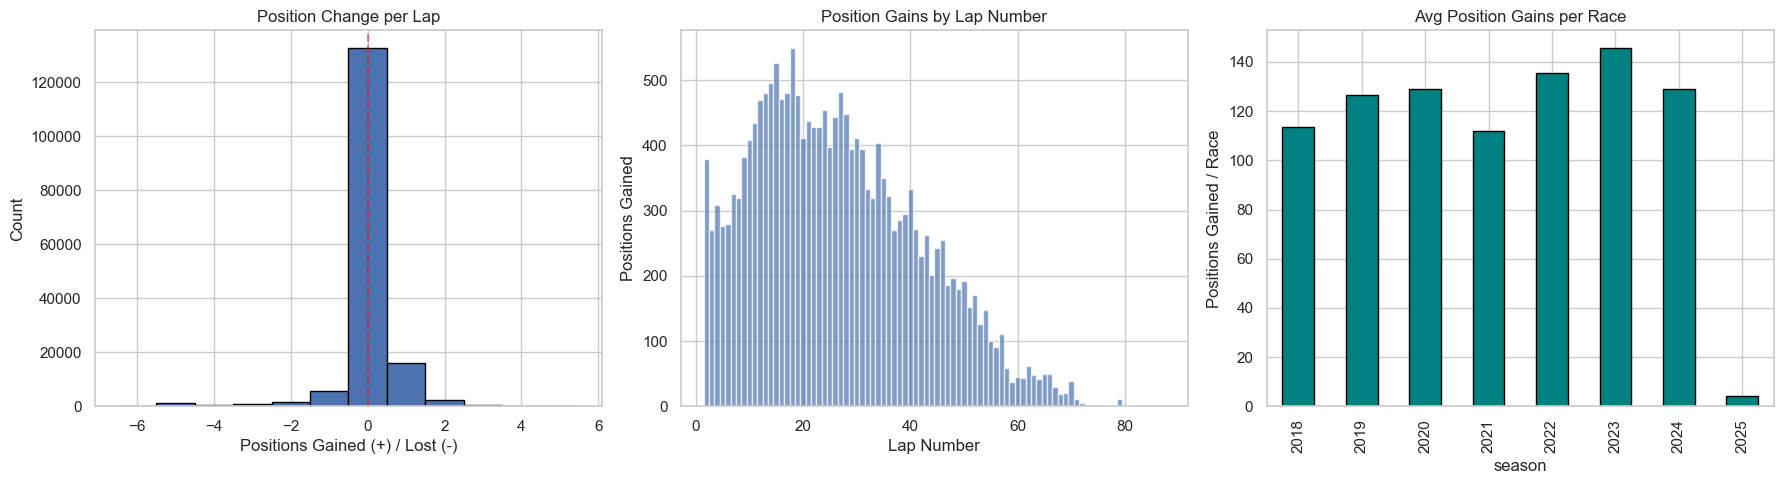


Total position gains: 19,084
Laps with no position change: 132,588 (82.1%)


In [7]:
pos_laps = laps.dropna(subset=["position"]).copy()
pos_laps = pos_laps.sort_values(["season", "round", "driver_abbrev", "lap_number"])

# Position change per lap
pos_laps["prev_position"] = pos_laps.groupby(
    ["season", "round", "driver_abbrev"]
)["position"].shift(1)
pos_laps["pos_change"] = pos_laps["prev_position"] - pos_laps["position"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Position change distribution
pos_changes = pos_laps["pos_change"].dropna()
pos_changes_capped = pos_changes.clip(-5, 5)
pos_changes_capped.hist(bins=range(-6, 7), ax=axes[0], edgecolor="black", align="left")
axes[0].set_title("Position Change per Lap")
axes[0].set_xlabel("Positions Gained (+) / Lost (-)")
axes[0].set_ylabel("Count")
axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.5)

# Overtakes by lap number
overtakes = pos_laps[pos_laps["pos_change"] > 0].copy()
overtakes_by_lap = overtakes.groupby("lap_number").size()
axes[1].bar(overtakes_by_lap.index, overtakes_by_lap.values, alpha=0.7, width=1.0)
axes[1].set_title("Position Gains by Lap Number")
axes[1].set_xlabel("Lap Number")
axes[1].set_ylabel("Positions Gained")

# Average position changes by season
overtake_rate = pos_laps[pos_laps["pos_change"] > 0].groupby("season").size()
race_count = pos_laps.groupby("season").apply(lambda g: g.groupby("round").ngroups)
overtakes_per_race = (overtake_rate / race_count).dropna()
overtakes_per_race.plot(kind="bar", ax=axes[2], color="teal", edgecolor="black")
axes[2].set_title("Avg Position Gains per Race")
axes[2].set_ylabel("Positions Gained / Race")

plt.tight_layout()
plt.show()

print(f"\nTotal position gains: {len(overtakes):,}")
print(f"Laps with no position change: {(pos_changes == 0).sum():,} ({(pos_changes == 0).mean() * 100:.1f}%)")

## 7. Sector Time Analysis

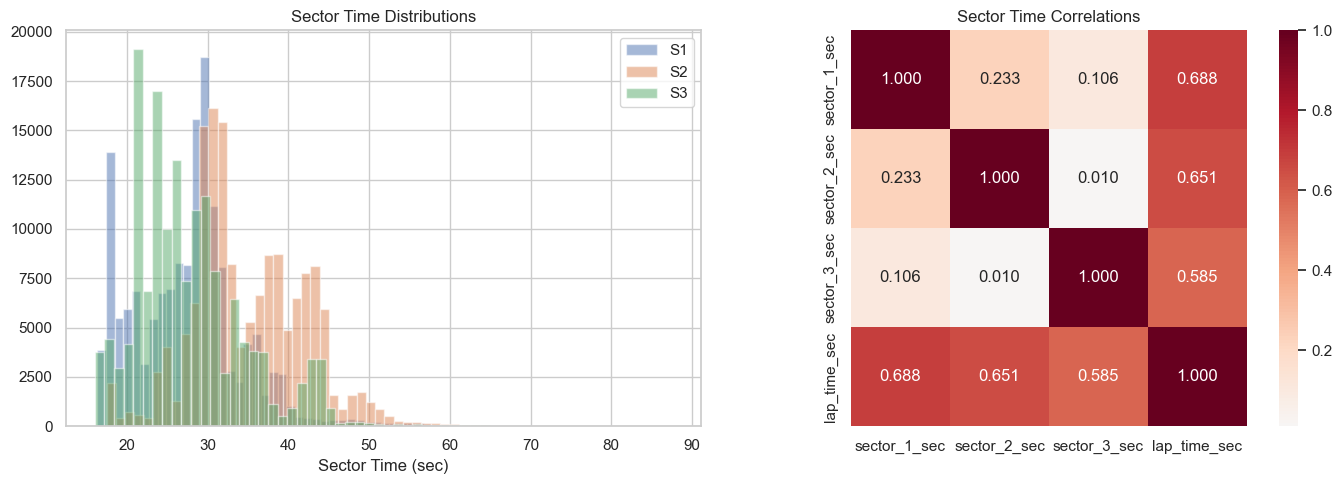

sector_1_sec: 30.4% of lap time
sector_2_sec: 38.9% of lap time
sector_3_sec: 30.7% of lap time


In [8]:
sector_cols = ["sector_1_sec", "sector_2_sec", "sector_3_sec"]
sector_laps = clean_laps.dropna(subset=sector_cols).copy()

if len(sector_laps) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Sector time distributions
    for i, col in enumerate(sector_cols):
        label = f"S{i+1}"
        axes[0].hist(sector_laps[col], bins=60, alpha=0.5, label=label)
    axes[0].set_title("Sector Time Distributions")
    axes[0].set_xlabel("Sector Time (sec)")
    axes[0].legend()

    # Sector correlations
    sector_corr = sector_laps[sector_cols + ["lap_time_sec"]].corr()
    sns.heatmap(sector_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                ax=axes[1], square=True)
    axes[1].set_title("Sector Time Correlations")

    plt.tight_layout()
    plt.show()

    # Sector contribution to lap time
    for col in sector_cols:
        pct = (sector_laps[col] / sector_laps["lap_time_sec"] * 100).mean()
        print(f"{col}: {pct:.1f}% of lap time")
else:
    print("No sector time data available (only available for FastF1 seasons 2018-2024).")

## 8. Track Status & Safety Cars

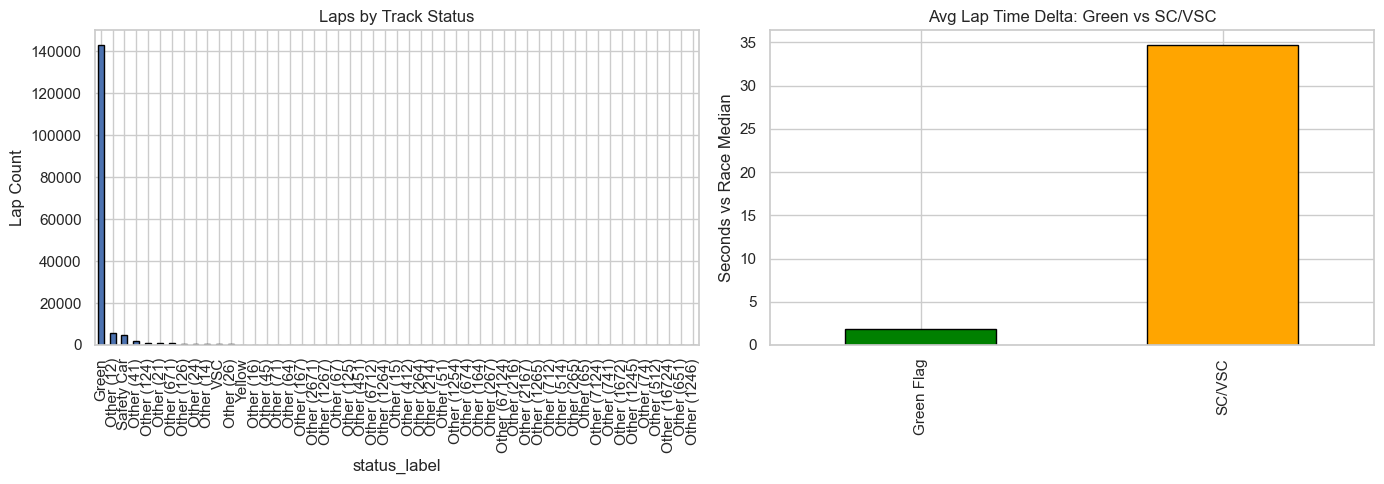


SC/VSC laps: 3.2% of all laps with track status


In [9]:
status_laps = laps[laps["track_status"].notna() & (laps["track_status"] != "")].copy()

if len(status_laps) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Track status distribution
    status_map = {
        "1": "Green", "2": "Yellow", "4": "Safety Car",
        "5": "Red Flag", "6": "VSC", "7": "VSC Ending"
    }
    status_laps["status_label"] = status_laps["track_status"].map(
        lambda x: status_map.get(str(x).strip(), f"Other ({x})")
    )
    status_counts = status_laps["status_label"].value_counts()
    status_counts.plot(kind="bar", ax=axes[0], edgecolor="black")
    axes[0].set_title("Laps by Track Status")
    axes[0].set_ylabel("Lap Count")

    # SC/VSC impact on lap times
    valid_status = status_laps.dropna(subset=["lap_time_sec"]).copy()
    valid_status["is_sc"] = valid_status["track_status"].isin(["4", "6", "7"])
    race_med = valid_status.groupby(["season", "round"])["lap_time_sec"].transform("median")
    valid_status["time_delta"] = valid_status["lap_time_sec"] - race_med
    sc_impact = valid_status.groupby("is_sc")["time_delta"].mean()
    sc_impact.index = ["Green Flag", "SC/VSC"]
    sc_impact.plot(kind="bar", ax=axes[1], color=["green", "orange"], edgecolor="black")
    axes[1].set_title("Avg Lap Time Delta: Green vs SC/VSC")
    axes[1].set_ylabel("Seconds vs Race Median")

    plt.tight_layout()
    plt.show()

    sc_pct = (status_laps["track_status"].isin(["4", "6", "7"]).sum() / len(status_laps)) * 100
    print(f"\nSC/VSC laps: {sc_pct:.1f}% of all laps with track status")
else:
    print("No track status data available (only available for FastF1 seasons 2018-2024).")

## 9. Data Completeness: FastF1 vs Jolpica

        total_laps  races  drivers  lap_time_%  sector_%  tire_%  position_%  track_status_%
season                                                                                      
2018         22337     21       20        98.0      97.9    48.0        99.8           100.0
2019         23676     21       20        98.8      98.1   100.0        99.9           100.0
2020         18352     17       23        97.6      97.7   100.0        99.8           100.0
2021         23758     22       21        98.1      97.6    99.7        99.9           100.0
2022         23577     22       22        97.8      97.8    98.6        99.8           100.0
2023         24422     22       22        98.2      97.8    99.9        99.8           100.0
2024         26606     24       24        99.2      98.0   100.0        99.9           100.0
2025          2400     24       21       100.0       0.0     0.0       100.0             0.0


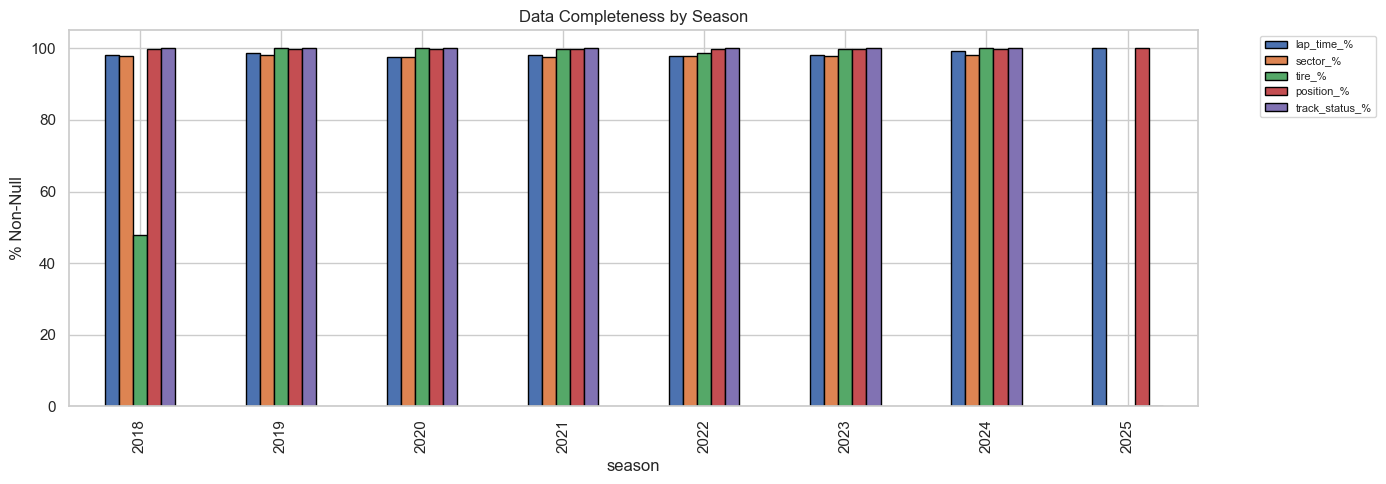

In [10]:
completeness = []
for season in sorted(laps["season"].unique()):
    s = laps[laps["season"] == season]
    row = {
        "season": season,
        "total_laps": len(s),
        "races": s["round"].nunique(),
        "drivers": s["driver_abbrev"].nunique(),
        "lap_time_%": (s["lap_time_sec"].notna().mean() * 100).round(1),
        "sector_%": (s["sector_1_sec"].notna().mean() * 100).round(1),
        "tire_%": (s["tire_compound"].notna().mean() * 100).round(1) if "tire_compound" in s.columns else 0,
        "position_%": (s["position"].notna().mean() * 100).round(1),
        "track_status_%": (s["track_status"].notna().mean() * 100).round(1) if "track_status" in s.columns else 0,
    }
    completeness.append(row)

comp_df = pd.DataFrame(completeness).set_index("season")
print(comp_df.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
pct_cols = [c for c in comp_df.columns if c.endswith("%")]
comp_df[pct_cols].plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Data Completeness by Season")
ax.set_ylabel("% Non-Null")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 10. Lap Time Correlation Heatmap

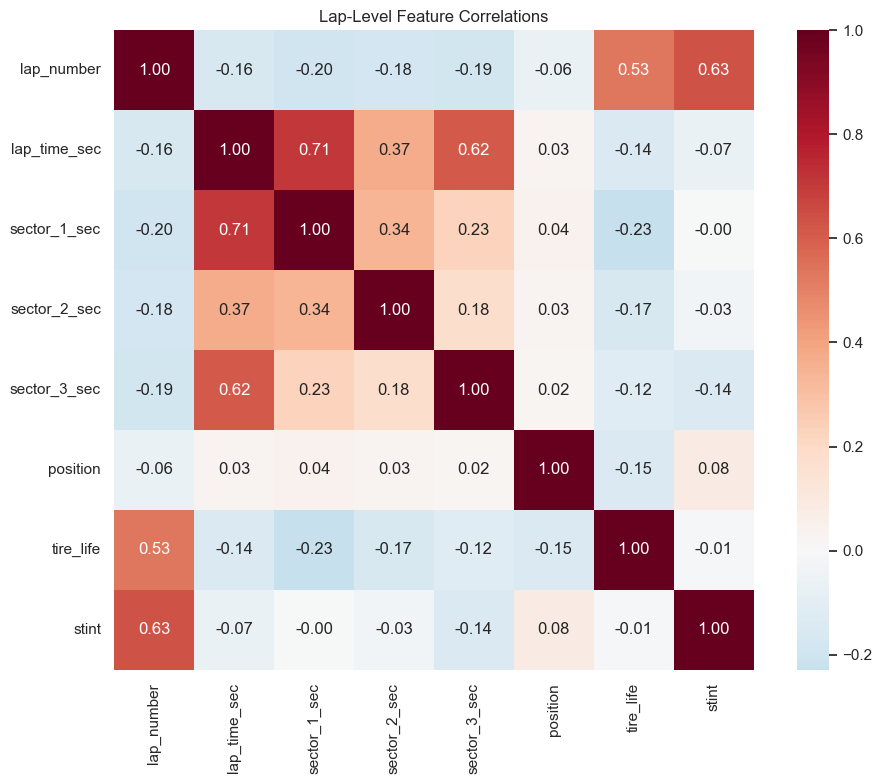

In [11]:
numeric_cols = [
    "lap_number", "lap_time_sec", "sector_1_sec", "sector_2_sec", "sector_3_sec",
    "position", "tire_life", "stint",
]
existing = [c for c in numeric_cols if c in laps.columns]
corr = laps[existing].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Lap-Level Feature Correlations")
plt.tight_layout()
plt.show()

## 11. Key Insights

- **Tire degradation** is clearly visible: lap times increase with tire life, with soft compounds degrading fastest
- **Pit stop windows** cluster around laps 15-25 and 35-45 (typical 2-stop strategy)
- **Position changes** are most frequent on lap 1 (start chaos) and after pit stops
- **Safety cars** add ~15-30 seconds to lap times, creating bunching that enables overtaking
- **Sector times** are highly correlated with total lap time â€” S2 typically longest
- **2025 data** from Jolpica lacks sector times, tire data, and track status â€” these features will be null for the most recent season
- **Data volume**: ~230k+ laps across 8 seasons provides strong signal for time-series modeling
- **Key features for time-series model**: tire degradation slope, pit window proximity, position delta, SC/VSC regime changes